# Final Evaluation

Train the OI Threshold strategy on **all** training data (5 stocks), then evaluate on **all** test data.

**Metric:**
```
score = 100 - 100 * (TOTAL_ALGO_BUY - TOTAL_ALGO_SELL) / (TOTAL_TWAP_BUY - TOTAL_TWAP_SELL)
```
Higher is better. 0 = match TWAP. Positive = beat TWAP (lower net cost).

**TWAP benchmark:** executes at the **first tick** of each minute (per project spec).

## 1. Load & Preprocess All Data

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

from utils.preprocessing import load_and_preprocess, detect_archetype
from utils.strategy import OIThresholdStrategy, precompute_minute_data, fit_strategy
from utils.signals import get_signal_fn

STOCKS = ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
DATA_DIR = 'data'

def load_split(stocks, suffix, data_dir='data'):
    """Load train or test CSVs for all stocks, add archetypes and TWAP columns."""
    frames = {}
    for t in stocks:
        df = pd.read_csv(f'{data_dir}/{t}_5levels_{suffix}.csv')
        parts = df['Time'].str.split(':', expand=True)
        df['seconds'] = (parts[0].astype(float) * 3600 +
                         parts[1].astype(float) * 60 +
                         parts[2].astype(float))
        df['minute_start'] = np.floor(df['seconds'] / 60) * 60
        df['mid'] = (df['BidPrice_1'] + df['AskPrice_1']) / 2
        df['spread'] = df['AskPrice_1'] - df['BidPrice_1']
        df['oi'] = df['BidSize_1'] / (df['BidSize_1'] + df['AskSize_1'])
        df['t_elapsed'] = df['seconds'] - df['minute_start']
        df['ticker'] = t
        frames[t] = df

    data = pd.concat(frames.values(), ignore_index=True)

    archetypes = {t: detect_archetype(frames[t]) for t in stocks}
    data['archetype'] = data['ticker'].map(archetypes)

    # Mean TWAP columns (needed by fit_strategy internally)
    twap_ask = data.groupby(['ticker', 'minute_start'])['AskPrice_1'].mean().rename('twap_ask')
    twap_bid = data.groupby(['ticker', 'minute_start'])['BidPrice_1'].mean().rename('twap_bid')
    data = data.merge(twap_ask, on=['ticker', 'minute_start'])
    data = data.merge(twap_bid, on=['ticker', 'minute_start'])

    # First-tick TWAP (per project spec: execute at beginning of each minute)
    first_ask = data.groupby(['ticker', 'minute_start'])['AskPrice_1'].first().rename('first_tick_ask')
    first_bid = data.groupby(['ticker', 'minute_start'])['BidPrice_1'].first().rename('first_tick_bid')
    data = data.merge(first_ask, on=['ticker', 'minute_start'])
    data = data.merge(first_bid, on=['ticker', 'minute_start'])

    return data, frames, archetypes

# Load train and test separately
train_data, train_frames, archetypes = load_split(STOCKS, 'train')
test_data, test_frames, _ = load_split(STOCKS, 'test')

print("TRAIN:")
for t in STOCKS:
    n = train_data.loc[train_data['ticker'] == t, 'minute_start'].nunique()
    med = train_frames[t]['spread'].median()
    print(f"  {t}: {archetypes[t]:6s}  ({n} min, {len(train_frames[t]):,} ticks, median spread = ${med:.4f})")

print(f"\nTEST:")
for t in STOCKS:
    n = test_data.loc[test_data['ticker'] == t, 'minute_start'].nunique()
    med = test_frames[t]['spread'].median()
    print(f"  {t}: {archetypes[t]:6s}  ({n} min, {len(test_frames[t]):,} ticks, median spread = ${med:.4f})")

TRAIN:
  AAPL: wide    (270 min, 255,360 ticks, median spread = $0.1700)
  AMZN: wide    (270 min, 175,338 ticks, median spread = $0.1400)
  GOOG: wide    (270 min, 100,048 ticks, median spread = $0.3000)
  INTC: penny   (270 min, 430,718 ticks, median spread = $0.0100)
  MSFT: penny   (270 min, 443,425 ticks, median spread = $0.0100)

TEST:
  AAPL: wide    (120 min, 145,031 ticks, median spread = $0.1100)
  AMZN: wide    (120 min, 94,410 ticks, median spread = $0.1100)
  GOOG: wide    (120 min, 47,868 ticks, median spread = $0.2400)
  INTC: penny   (120 min, 193,322 ticks, median spread = $0.0100)
  MSFT: penny   (120 min, 225,340 ticks, median spread = $0.0100)


## 2. Train on ALL Training Data

In [2]:
from utils.config import DEFAULT_CONFIG

config = DEFAULT_CONFIG.copy()
config['stocks'] = STOCKS

# Fit on entire training set (no internal train/test split — test data is separate files)
fitted, details = fit_strategy(OIThresholdStrategy, train_data, config, signal_fn='oi')

print("Fitted parameters:")
for arch, params in fitted.items():
    print(f"  {arch:6s}: theta_imb={params['theta_imb']:.4f}, theta_spread=${params['theta_spread']:.4f}")

Fitted parameters:
  penny : theta_imb=0.9500, theta_spread=$0.0116
  wide  : theta_imb=0.5200, theta_spread=$0.1211


## 3. Evaluate on ALL Test Data

In [3]:
from utils.signals import oi_signal

def evaluate_test(test_data, fitted, stocks):
    """Run strategy on test data. TWAP = first-tick execution (per project spec)."""
    sig_fn = get_signal_fn('oi')
    records = []

    for (ticker, minute), grp in test_data.groupby(['ticker', 'minute_start']):
        if len(grp) < 5:
            continue
        arch = grp['archetype'].iloc[0]
        params = fitted[arch]
        strat = OIThresholdStrategy(params=params, signal_fn=sig_fn)

        # Strategy execution
        buy_price = strat.execute_minute(grp, 'buy')
        sell_price = strat.execute_minute(grp, 'sell')

        # TWAP = first tick of the minute
        twap_buy = grp['first_tick_ask'].iloc[0]
        twap_sell = grp['first_tick_bid'].iloc[0]

        records.append({
            'ticker': ticker,
            'minute_start': minute,
            'archetype': arch,
            'algo_buy': buy_price,
            'algo_sell': sell_price,
            'twap_buy': twap_buy,
            'twap_sell': twap_sell,
        })

    return pd.DataFrame(records)

results = evaluate_test(test_data, fitted, STOCKS)
print(f"Evaluated {len(results)} minutes across {results['ticker'].nunique()} stocks")

Evaluated 600 minutes across 5 stocks


## 4. Compute Score

```
score = 100 - 100 * (TOTAL_ALGO_BUY - TOTAL_ALGO_SELL) / (TOTAL_TWAP_BUY - TOTAL_TWAP_SELL)
```

In [4]:
def compute_score(df):
    """Compute the project metric."""
    total_algo_buy = df['algo_buy'].sum()
    total_algo_sell = df['algo_sell'].sum()
    total_twap_buy = df['twap_buy'].sum()
    total_twap_sell = df['twap_sell'].sum()

    algo_cost = total_algo_buy - total_algo_sell
    twap_cost = total_twap_buy - total_twap_sell

    score = 100 - 100 * algo_cost / twap_cost
    return score, algo_cost, twap_cost

# Also evaluate on training data for train vs test comparison
train_results = evaluate_test(train_data, fitted, STOCKS)

# Overall scores
test_score, test_ac, test_tc = compute_score(results)
train_score, train_ac, train_tc = compute_score(train_results)

print("=" * 60)
print(f"OVERALL SCORES")
print(f"=" * 60)
print(f"  Train: {train_score:.4f}    Test: {test_score:.4f}    Delta: {test_score - train_score:+.4f}")
print(f"  Train savings: ${train_tc - train_ac:,.2f}    Test savings: ${test_tc - test_ac:,.2f}")

# Per-stock train vs test with delta
print(f"\nPER-STOCK SCORES (Train vs Test):")
print(f"  {'Stock':6s} {'Type':6s} {'Train':>8s} {'Test':>8s} {'Delta':>8s}")
print(f"  {'-'*6} {'-'*6} {'-'*8} {'-'*8} {'-'*8}")

for ticker in STOCKS:
    train_sub = train_results[train_results['ticker'] == ticker]
    test_sub = results[results['ticker'] == ticker]
    tr_s, _, _ = compute_score(train_sub)
    te_s, _, _ = compute_score(test_sub)
    delta = te_s - tr_s
    print(f"  {ticker:6s} {archetypes[ticker]:6s} {tr_s:8.1f} {te_s:8.1f} {delta:+8.1f}")

# Per-archetype
print(f"\nPER-ARCHETYPE SCORES (Train vs Test):")
print(f"  {'':15s} {'Train':>8s} {'Test':>8s} {'Delta':>8s}")
print(f"  {'-'*15} {'-'*8} {'-'*8} {'-'*8}")
for arch in ['penny', 'wide']:
    train_sub = train_results[train_results['archetype'] == arch]
    test_sub = results[results['archetype'] == arch]
    tr_s, _, _ = compute_score(train_sub)
    te_s, _, _ = compute_score(test_sub)
    tickers = ', '.join(test_sub['ticker'].unique())
    print(f"  {arch.title():6s} ({tickers:6s}) {tr_s:8.1f} {te_s:8.1f} {te_s - tr_s:+8.1f}")

OVERALL SCORES
  Train: 43.7654    Test: 48.8393    Delta: +5.0739
  Train savings: $72.97    Test savings: $27.77

PER-STOCK SCORES (Train vs Test):
  Stock  Type      Train     Test    Delta
  ------ ------ -------- -------- --------
  AAPL   wide       53.3     39.8    -13.5
  AMZN   wide       40.2     35.3     -4.9
  GOOG   wide       35.2     55.0    +19.7
  INTC   penny     109.8    100.0     -9.8
  MSFT   penny     118.9    120.0     +1.1

PER-ARCHETYPE SCORES (Train vs Test):
                     Train     Test    Delta
  --------------- -------- -------- --------
  Penny  (INTC, MSFT)    114.3    110.0     -4.3
  Wide   (AAPL, AMZN, GOOG)     41.4     46.1     +4.8


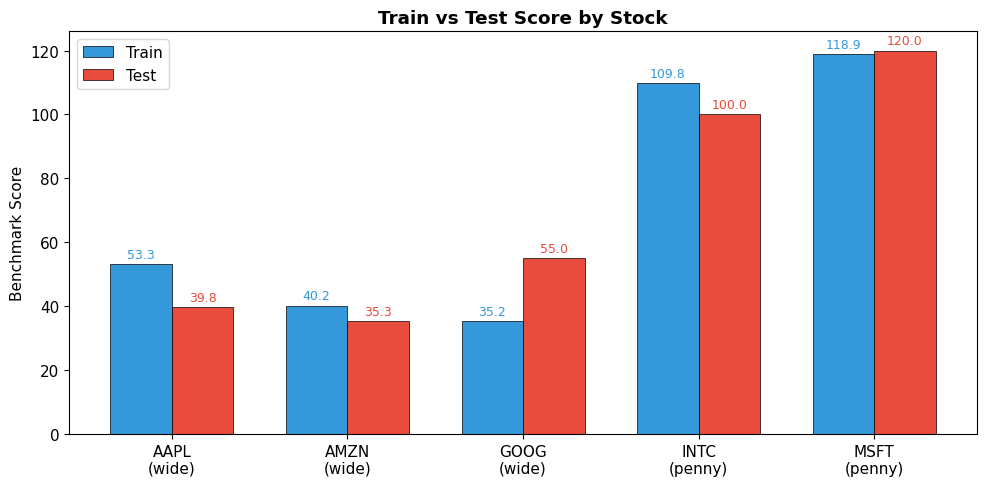

In [5]:
# Plot: Train vs Test scores per stock (grouped bar chart)
train_scores = []
test_scores = []
for ticker in STOCKS:
    tr_s, _, _ = compute_score(train_results[train_results['ticker'] == ticker])
    te_s, _, _ = compute_score(results[results['ticker'] == ticker])
    train_scores.append(tr_s)
    test_scores.append(te_s)

x = np.arange(len(STOCKS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_train = ax.bar(x - width/2, train_scores, width, label='Train', color='#3498db',
                     edgecolor='black', linewidth=0.5)
bars_test = ax.bar(x + width/2, test_scores, width, label='Test', color='#e74c3c',
                    edgecolor='black', linewidth=0.5)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, color='#3498db')
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n({archetypes[t]})' for t in STOCKS])
ax.set_ylabel('Benchmark Score')
ax.set_title('Train vs Test Score by Stock', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig('assets/final_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Stock Detail (Test Set)

In [6]:
# Per-stock detail: improvement ($), improvement (spread units), win rate, benchmark score
detail_rows = []
for ticker in STOCKS:
    sub = results[results['ticker'] == ticker]
    arch = archetypes[ticker]
    med_spr = test_frames[ticker]['spread'].median()

    # Mean per-minute improvement (algo beats TWAP)
    # Buy improvement: TWAP_buy - algo_buy (positive = bought cheaper)
    # Sell improvement: algo_sell - TWAP_sell (positive = sold higher)
    buy_imp = (sub['twap_buy'] - sub['algo_buy']).mean()
    sell_imp = (sub['algo_sell'] - sub['twap_sell']).mean()
    avg_imp = (buy_imp + sell_imp) / 2
    avg_imp_spr = avg_imp / med_spr

    # Win rate: fraction of minutes where algo net cost < TWAP net cost
    algo_net = sub['algo_buy'] - sub['algo_sell']
    twap_net = sub['twap_buy'] - sub['twap_sell']
    win_rate = (algo_net < twap_net).mean()

    # Benchmark score
    score, _, _ = compute_score(sub)

    detail_rows.append({
        'Stock': ticker, 'Archetype': arch,
        'Improvement ($)': avg_imp, 'Improvement (spr)': avg_imp_spr,
        'Win Rate': win_rate, 'Benchmark': score,
    })

detail = pd.DataFrame(detail_rows)

print(f"  {'Stock':6s} {'Type':6s} {'Improvement ($)':>16s} {'Improvement (spr)':>18s} {'Win Rate':>10s} {'Benchmark':>10s}")
print(f"  {'-'*6} {'-'*6} {'-'*16} {'-'*18} {'-'*10} {'-'*10}")
for _, r in detail.iterrows():
    print(f"  {r['Stock']:6s} {r['Archetype']:6s} "
          f"{r['Improvement ($)']:>+15.4f}$ {r['Improvement (spr)']:>+17.3f} "
          f"{r['Win Rate']:>9.1%} {r['Benchmark']:>10.1f}")

  Stock  Type    Improvement ($)  Improvement (spr)   Win Rate  Benchmark
  ------ ------ ---------------- ------------------ ---------- ----------
  AAPL   wide           +0.0233$            +0.212     65.8%       39.8
  AMZN   wide           +0.0199$            +0.181     66.7%       35.3
  GOOG   wide           +0.0615$            +0.256     75.0%       55.0
  INTC   penny          +0.0050$            +0.500     70.0%      100.0
  MSFT   penny          +0.0060$            +0.600     80.0%      120.0


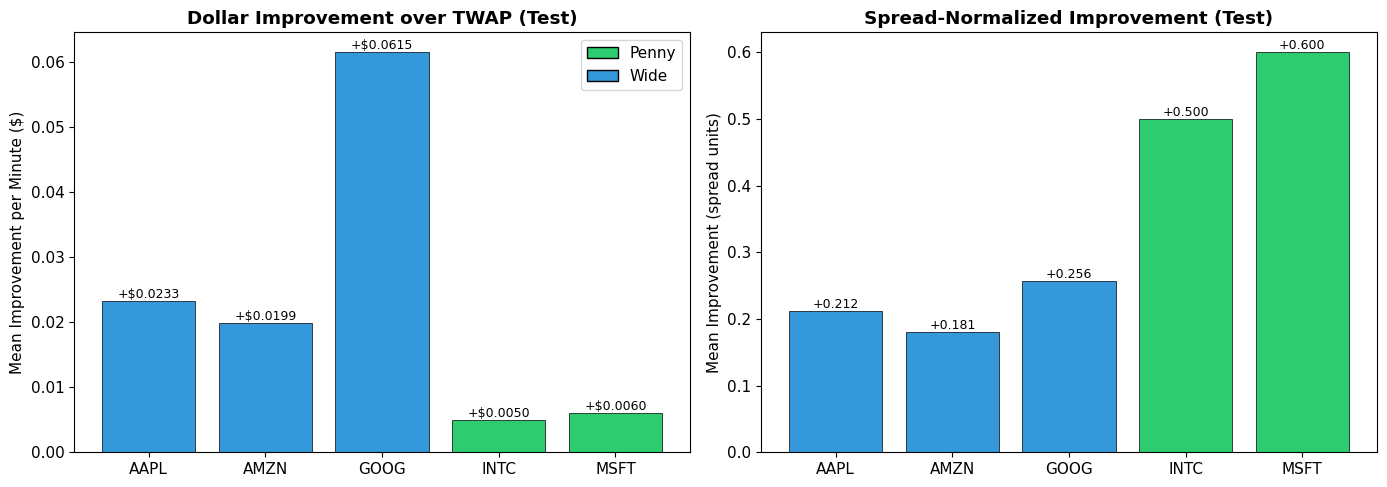

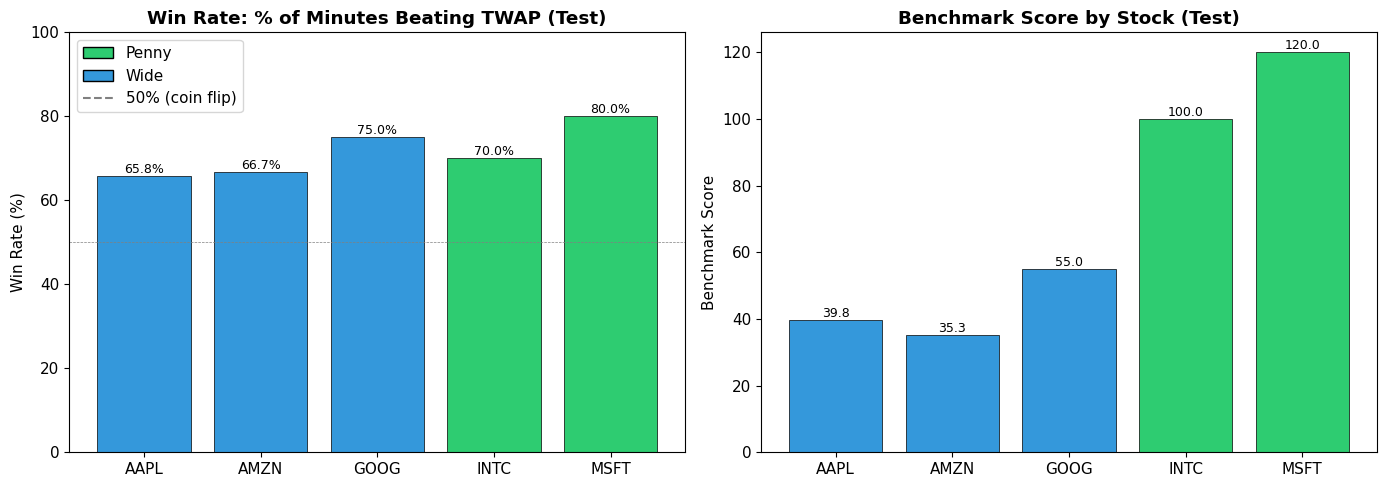

In [7]:
# Plot 1: Improvement in dollars and spread units (side by side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if archetypes[t] == 'penny' else '#3498db' for t in STOCKS]

bars = ax1.bar(STOCKS, detail['Improvement ($)'].values, color=colors,
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, detail['Improvement ($)'].values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'+${val:.4f}', ha='center', va='bottom', fontsize=9)
ax1.set_ylabel('Mean Improvement per Minute ($)')
ax1.set_title('Dollar Improvement over TWAP (Test)', fontweight='bold')
ax1.axhline(0, color='black', lw=0.5)

bars = ax2.bar(STOCKS, detail['Improvement (spr)'].values, color=colors,
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, detail['Improvement (spr)'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'+{val:.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Mean Improvement (spread units)')
ax2.set_title('Spread-Normalized Improvement (Test)', fontweight='bold')
ax2.axhline(0, color='black', lw=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', edgecolor='black', label='Penny'),
                   Patch(facecolor='#3498db', edgecolor='black', label='Wide')]
ax1.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig('assets/final_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Win rate and benchmark score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(STOCKS, detail['Win Rate'].values * 100, color=colors,
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, detail['Win Rate'].values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1%}', ha='center', va='bottom', fontsize=9)
ax1.set_ylabel('Win Rate (%)')
ax1.set_title('Win Rate: % of Minutes Beating TWAP (Test)', fontweight='bold')
ax1.axhline(50, color='gray', lw=0.5, ls='--')
ax1.set_ylim(0, 100)

bars = ax2.bar(STOCKS, detail['Benchmark'].values, color=colors,
               edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, detail['Benchmark'].values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Benchmark Score')
ax2.set_title('Benchmark Score by Stock (Test)', fontweight='bold')
ax2.axhline(0, color='black', lw=0.5)

ax1.legend(handles=legend_elements + [plt.Line2D([0],[0], color='gray', ls='--', label='50% (coin flip)')])
plt.tight_layout()
plt.savefig('assets/final_winrate_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

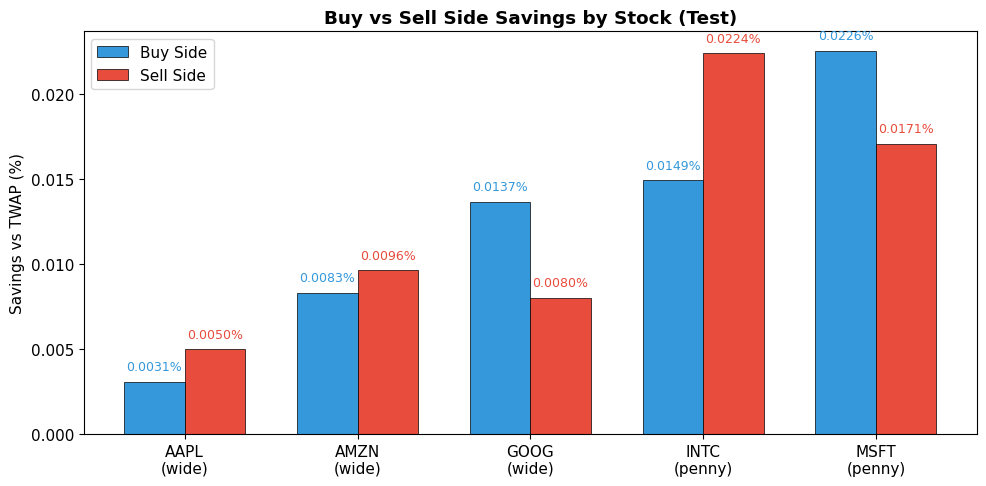

In [8]:
# Plot: Buy vs Sell side savings per stock (test data)
# Savings = (TWAP_price - algo_price) / TWAP_price * 100 for buys
# Savings = (algo_price - TWAP_price) / TWAP_price * 100 for sells
buy_savings = []
sell_savings = []
for ticker in STOCKS:
    sub = results[results['ticker'] == ticker]
    buy_sav = (sub['twap_buy'].sum() - sub['algo_buy'].sum()) / sub['twap_buy'].sum() * 100
    sell_sav = (sub['algo_sell'].sum() - sub['twap_sell'].sum()) / sub['twap_sell'].sum() * 100
    buy_savings.append(buy_sav)
    sell_savings.append(sell_sav)

x = np.arange(len(STOCKS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_buy = ax.bar(x - width/2, buy_savings, width, label='Buy Side', color='#3498db',
                  edgecolor='black', linewidth=0.5)
bars_sell = ax.bar(x + width/2, sell_savings, width, label='Sell Side', color='#e74c3c',
                   edgecolor='black', linewidth=0.5)

for bar in bars_buy:
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0005,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=9, color='#3498db')
for bar in bars_sell:
    val = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.0005,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=9, color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n({archetypes[t]})' for t in STOCKS])
ax.set_ylabel('Savings vs TWAP (%)')
ax.set_title('Buy vs Sell Side Savings by Stock (Test)', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout()
plt.savefig('assets/final_buy_vs_sell.png', dpi=150, bbox_inches='tight')
plt.show()